# 08 · Three-Model Comparison & War Shock Analysis

**Project:** War Shocks & Global Financial Risk Spillover  
**Models:** VAR (baseline) · LSTM · GRU  
**Evaluation:** MSE / MAE / RMSE / MAPE / DirAcc, h = 1 / 5 / 10 / 22  
**Ref:** Kumar et al. (2024, arXiv:2410.16858); Diebold & Yilmaz (2009, 2012)  

**Table format:** Row = Market (8 indices + AVERAGE), Column = Model × Horizon (VAR/LSTM/GRU × h=1/5/10/22)  
Mirrors Kumar et al. (2024) Table 2/3 structure, extended with regime-conditional analysis.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.var_models import EQUITY_COLS, HORIZONS

FIG_DIR   = os.path.join("..", "outputs", "figures")
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

MARKET_LABELS = {
    "SP500_vol":    "S&P 500",
    "STOXX600_vol": "STOXX 600",
    "FTSE100_vol":  "FTSE 100",
    "DAX_vol":      "DAX",
    "Nikkei_vol":   "Nikkei",
    "HangSeng_vol": "Hang Seng",
    "MSCI_EM_vol":  "MSCI EM",
    "CSI300_vol":   "CSI 300",
}

MODEL_COLORS = {"VAR": "#4575b4", "LSTM": "#d7191c", "GRU": "#1a9641"}

print(f"EQUITY_COLS : {EQUITY_COLS}")
print(f"HORIZONS    : {HORIZONS}")

EQUITY_COLS : ['SP500_vol', 'STOXX600_vol', 'FTSE100_vol', 'DAX_vol', 'Nikkei_vol', 'HangSeng_vol', 'MSCI_EM_vol', 'CSI300_vol']
HORIZONS    : [1, 5, 10, 22]


## 1 · Load All Model Metrics

In [24]:
def load_metrics(model_prefix):
    """Load per-horizon metrics for a given model prefix (var / lstm / gru)."""
    frames = []
    for h in HORIZONS:
        path = os.path.join(TABLE_DIR, f"table_{model_prefix}_metrics_h{h}.xlsx")
        df = pd.read_excel(path)
        df["Horizon"] = h
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

metrics_var  = load_metrics("var")
metrics_lstm = load_metrics("lstm")
metrics_gru  = load_metrics("gru")

# Tag model name
for df, name in [(metrics_var, "VAR"), (metrics_lstm, "LSTM"), (metrics_gru, "GRU")]:
    df["Model"] = name

all_metrics = pd.concat([metrics_var, metrics_lstm, metrics_gru], ignore_index=True)

print("Metrics loaded:")
print(f"  VAR  : {metrics_var.shape}")
print(f"  LSTM : {metrics_lstm.shape}")
print(f"  GRU  : {metrics_gru.shape}")
print(f"Columns: {list(all_metrics.columns)}")

Metrics loaded:
  VAR  : (72, 10)
  LSTM : (72, 10)
  GRU  : (72, 10)
Columns: ['Market', 'MSE', 'MAE', 'RMSE', 'MAPE', 'Dir_Acc', 'Period', 'Horizon', 'Label', 'Model']


## 2 · Table 1 · Master Comparison Table

**Format:** Row = Market, Column = Model × Horizon  
**Metric shown:** MSE (primary), with MAPE in parentheses.  
Separate sub-tables produced for Val and Test periods.

In [36]:
MARKET_KEY_MAP = {col.replace("_vol", ""): col for col in EQUITY_COLS}

def build_master_table(all_metrics, period_label, metric_primary="MSE", metric_secondary="MAPE"):
    """
    Build wide-format comparison table.
    Rows = markets (8 indices + AVERAGE)
    Cols = Model x Horizon
    Cell = primary_metric (secondary_metric%)
    """
    # Filter to correct period
    sub = all_metrics[all_metrics["Label"].str.contains(period_label)].copy()

    rows = []
    market_keys = list(MARKET_KEY_MAP.keys()) + ["AVERAGE"]
    
    for mkt_key in market_keys:
        display_name = MARKET_LABELS.get(MARKET_KEY_MAP.get(mkt_key, mkt_key), mkt_key)
        row = {"Market": display_name}
        for model in ["VAR", "LSTM", "GRU"]:
            for h in HORIZONS:
                cell_data = sub[
                    (sub["Model"] == model) &
                    (sub["Horizon"] == h) &
                    (sub["Market"] == mkt_key)
                ]
                if len(cell_data) == 0:
                    row[f"{model}_h{h}"] = "—"
                else:
                    p_val = cell_data.iloc[0][metric_primary]
                    s_val = cell_data.iloc[0][metric_secondary]
                    row[f"{model}_h{h}"] = f"{p_val:.6f} ({s_val:.1f}%)"
        rows.append(row)

    result = pd.DataFrame(rows)
    result = result.set_index("Market")

    # Multi-level column header
    tuples = [(model, f"h={h}") for model in ["VAR", "LSTM", "GRU"] for h in HORIZONS]
    result.columns = pd.MultiIndex.from_tuples(tuples, names=["Model", "Horizon"])
    return result


table_val  = build_master_table(all_metrics, "Val")
table_test = build_master_table(all_metrics, "Test")

print("=" * 80)
print("TABLE 1A — VAL PERIOD  |  Cell: MSE (MAPE%)")
print("=" * 80)
print(table_val.to_string())

print("\n" + "=" * 80)
print("TABLE 1B — TEST PERIOD  |  Cell: MSE (MAPE%)")
print("=" * 80)
print(table_test.to_string())

TABLE 1A — VAL PERIOD  |  Cell: MSE (MAPE%)
Model                  VAR                                                                   LSTM                                                                    GRU                                                      
Horizon                h=1               h=5              h=10              h=22              h=1               h=5              h=10              h=22              h=1               h=5              h=10              h=22
Market                                                                                                                                                                                                                        
S&P 500    0.000853 (8.1%)  0.003734 (20.2%)  0.010147 (32.6%)  0.026854 (51.0%)  0.000554 (6.8%)  0.003555 (23.0%)  0.008574 (32.8%)  0.026969 (49.3%)  0.000462 (6.9%)  0.003080 (17.7%)  0.008730 (29.3%)  0.026254 (52.8%)
STOXX 600  0.000581 (8.9%)  0.002096 (21.2%)  0.005511 (33.9%)  

## 3 · Table 2 · AVERAGE Summary (Clean 3-model × 4-horizon)

In [26]:
def build_average_summary(all_metrics):
    """
    Clean summary table for AVERAGE row only.
    Rows = Period × Horizon
    Cols = Model × Metric
    """
    rows = []
    for period in ["Val", "Test"]:
        for h in HORIZONS:
            row = {"Period": period, "Horizon": f"h={h}"}
            for model in ["VAR", "LSTM", "GRU"]:
                cell = all_metrics[
                    (all_metrics["Model"] == model) &
                    (all_metrics["Horizon"] == h) &
                    (all_metrics["Market"] == "AVERAGE") &
                    (all_metrics["Label"].str.contains(period))
                ]
                if len(cell) > 0:
                    r = cell.iloc[0]
                    row[f"{model}_MSE"]    = round(r["MSE"], 6)
                    row[f"{model}_MAE"]    = round(r["MAE"], 4)
                    row[f"{model}_RMSE"]   = round(r["RMSE"], 4)
                    row[f"{model}_MAPE"]   = round(r["MAPE"], 2)
                    row[f"{model}_DirAcc"] = round(r["Dir_Acc"], 3)
            rows.append(row)
    return pd.DataFrame(rows)


summary_df = build_average_summary(all_metrics)

# Mark best model per row per metric
metrics_list = ["MSE", "MAE", "RMSE", "MAPE"]
for metric in metrics_list:
    cols = [f"{m}_{metric}" for m in ["VAR", "LSTM", "GRU"]]
    summary_df[f"Best_{metric}"] = summary_df[cols].idxmin(axis=1).str.replace(f"_{metric}", "")

print("=" * 90)
print("TABLE 2 — AVERAGE METRICS SUMMARY (VAR vs LSTM vs GRU)")
print("=" * 90)
display_cols = ["Period", "Horizon"] + \
               [f"{m}_{met}" for m in ["VAR","LSTM","GRU"] for met in ["MSE","MAPE","DirAcc"]]
print(summary_df[display_cols].to_string(index=False))

print("\n--- Best model per metric (MSE) ---")
print(summary_df[["Period","Horizon","Best_MSE","Best_MAE","Best_RMSE","Best_MAPE"]].to_string(index=False))

TABLE 2 — AVERAGE METRICS SUMMARY (VAR vs LSTM vs GRU)
Period Horizon  VAR_MSE  VAR_MAPE  VAR_DirAcc  LSTM_MSE  LSTM_MAPE  LSTM_DirAcc  GRU_MSE  GRU_MAPE  GRU_DirAcc
   Val     h=1 0.000607      7.88       0.493  0.000364       5.81        0.532 0.000381      6.14       0.532
   Val     h=5 0.002259     17.49       0.475  0.002017      16.54        0.479 0.001965     15.90       0.481
   Val    h=10 0.005551     26.83       0.469  0.004788      26.07        0.486 0.004506     25.91       0.492
   Val    h=22 0.014307     40.49       0.491  0.013613      39.68        0.490 0.013839     41.83       0.478
  Test     h=1 0.000556      7.35       0.515  0.000262       5.95        0.534 0.000270      6.17       0.543
  Test     h=5 0.002027     16.10       0.493  0.001672      16.39        0.502 0.001611     14.92       0.505
  Test    h=10 0.003910     24.37       0.485  0.003565      25.06        0.497 0.003549     25.21       0.496
  Test    h=22 0.007464     37.95       0.510  0.007164  

## 4 · Table 3 · Regime-Conditional Metrics (War Shock Analysis)

Core contribution: VAR vs LSTM vs GRU under B: War-Only / D: War+Crisis / E: Sol/COVID  
Following Kumar et al. (2024) robustness test framework (their §5.5), extended to war-regime analysis.

In [27]:
from src.data_loader import DATA_PROC_DIR
from src.var_models import compute_metrics

VAL_START        = "2019-01-01"
VAL_END          = "2021-12-31"
SOLEIMANI_START  = "2020-01-03"
SOLEIMANI_END    = "2020-03-31"

war_df = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx", index_col=0, parse_dates=True)

def load_actuals_forecasts(model_prefix):
    """Load actual/forecast val h=1 DataFrames."""
    act = pd.read_excel(os.path.join(TABLE_DIR, f"{model_prefix}_actual_val.xlsx"),
                        index_col=0, parse_dates=True)
    fc  = pd.read_excel(os.path.join(TABLE_DIR, f"{model_prefix}_forecast_val.xlsx"),
                        index_col=0, parse_dates=True)
    return act, fc

act_var,  fc_var  = load_actuals_forecasts("var")
act_lstm, fc_lstm = load_actuals_forecasts("lstm")
act_gru,  fc_gru  = load_actuals_forecasts("gru")

print(f"VAR  actuals shape  : {act_var.shape}")
print(f"LSTM actuals shape  : {act_lstm.shape}")
print(f"GRU  actuals shape  : {act_gru.shape}")

VAR  actuals shape  : (594, 8)
LSTM actuals shape  : (533, 8)
GRU  actuals shape  : (533, 8)


In [28]:
def compute_regime_metrics(act_df, fc_df, war_df):
    """Compute regime-conditional metrics for one model's val h=1 outputs."""
    war_val   = war_df["mideast_war"].reindex(act_df.index).fillna(0).astype(int)
    crisis_val = war_df["any_crisis"].reindex(act_df.index).fillna(0).astype(int)
    sol_flag  = ((act_df.index >= SOLEIMANI_START) & (act_df.index <= SOLEIMANI_END))

    regime_masks = {
        "B: War-Only"  : (war_val == 1) & (crisis_val == 0) & ~sol_flag,
        "D: War+Crisis": (war_val == 1) & (crisis_val == 1) & ~sol_flag,
        "E: Sol/COVID" : sol_flag,
    }

    results = {}
    for name, mask in regime_masks.items():
        n = mask.sum()
        if n < 10:
            results[name] = {"n": n, "MSE": np.nan, "RMSE": np.nan,
                             "MAPE": np.nan, "Dir_Acc": np.nan}
            continue
        m   = compute_metrics(act_df[mask], fc_df[mask], label=name)
        avg = m[m["Market"] == "AVERAGE"].iloc[0]
        results[name] = {
            "n"      : int(n),
            "MSE"    : round(avg["MSE"],    6),
            "RMSE"   : round(avg["RMSE"],   4),
            "MAPE"   : round(avg["MAPE"],   2),
            "Dir_Acc": round(avg["Dir_Acc"], 3),
        }
    return results


regime_var  = compute_regime_metrics(act_var,  fc_var,  war_df)
regime_lstm = compute_regime_metrics(act_lstm, fc_lstm, war_df)
regime_gru  = compute_regime_metrics(act_gru,  fc_gru,  war_df)

# Build regime comparison DataFrame
regime_names = ["B: War-Only", "D: War+Crisis", "E: Sol/COVID"]
regime_rows  = []
for regime in regime_names:
    row = {"Regime": regime}
    for model, res in [("VAR", regime_var), ("LSTM", regime_lstm), ("GRU", regime_gru)]:
        r = res[regime]
        row[f"{model}_n"]       = r["n"]
        row[f"{model}_MSE"]     = r["MSE"]
        row[f"{model}_RMSE"]    = r["RMSE"]
        row[f"{model}_MAPE"]    = r["MAPE"]
        row[f"{model}_DirAcc"]  = r["Dir_Acc"]
    regime_rows.append(row)

regime_df = pd.DataFrame(regime_rows).set_index("Regime")

print("=" * 80)
print("TABLE 3 — REGIME-CONDITIONAL METRICS (Val, h=1, AVERAGE across markets)")
print("(A: Calm = 0 obs; mideast_war=1 since 2011-03-15)")
print("=" * 80)
print(regime_df[["VAR_n","VAR_MSE","VAR_MAPE","VAR_DirAcc",
                 "LSTM_n","LSTM_MSE","LSTM_MAPE","LSTM_DirAcc",
                 "GRU_n","GRU_MSE","GRU_MAPE","GRU_DirAcc"]].to_string())

# D/B amplification ratios
print("\n--- Crisis-on-War Amplification Ratio D/B (MSE) ---")
for model, res in [("VAR", regime_var), ("LSTM", regime_lstm), ("GRU", regime_gru)]:
    b_mse = res["B: War-Only"]["MSE"]
    d_mse = res["D: War+Crisis"]["MSE"]
    ratio = d_mse / b_mse
    print(f"  {model:4s}: B={b_mse:.6f}  D={d_mse:.6f}  D/B = {ratio:.3f}x")

TABLE 3 — REGIME-CONDITIONAL METRICS (Val, h=1, AVERAGE across markets)
(A: Calm = 0 obs; mideast_war=1 since 2011-03-15)
               VAR_n   VAR_MSE  VAR_MAPE  VAR_DirAcc  LSTM_n  LSTM_MSE  LSTM_MAPE  LSTM_DirAcc  GRU_n   GRU_MSE  GRU_MAPE  GRU_DirAcc
Regime                                                                                                                               
B: War-Only      430  0.000314      7.98       0.490     369  0.000154       5.71        0.527    369  0.000157      6.05       0.531
D: War+Crisis    127  0.000896      6.83       0.504     127  0.000592       5.54        0.543    127  0.000693      5.82       0.537
E: Sol/COVID      37  0.003022     10.25       0.503      37  0.001675       7.70        0.569     37  0.001539      8.06       0.566

--- Crisis-on-War Amplification Ratio D/B (MSE) ---
  VAR : B=0.000314  D=0.000896  D/B = 2.854x
  LSTM: B=0.000154  D=0.000592  D/B = 3.844x
  GRU : B=0.000157  D=0.000693  D/B = 4.414x


## 5 · Fig 12 · MSE Comparison by Horizon (Val & Test)

Grouped bar chart: VAR vs LSTM vs GRU across h = 1, 5, 10, 22  
Mirrors Kumar et al. (2024) Fig. style for cross-model forecast horizon comparison.

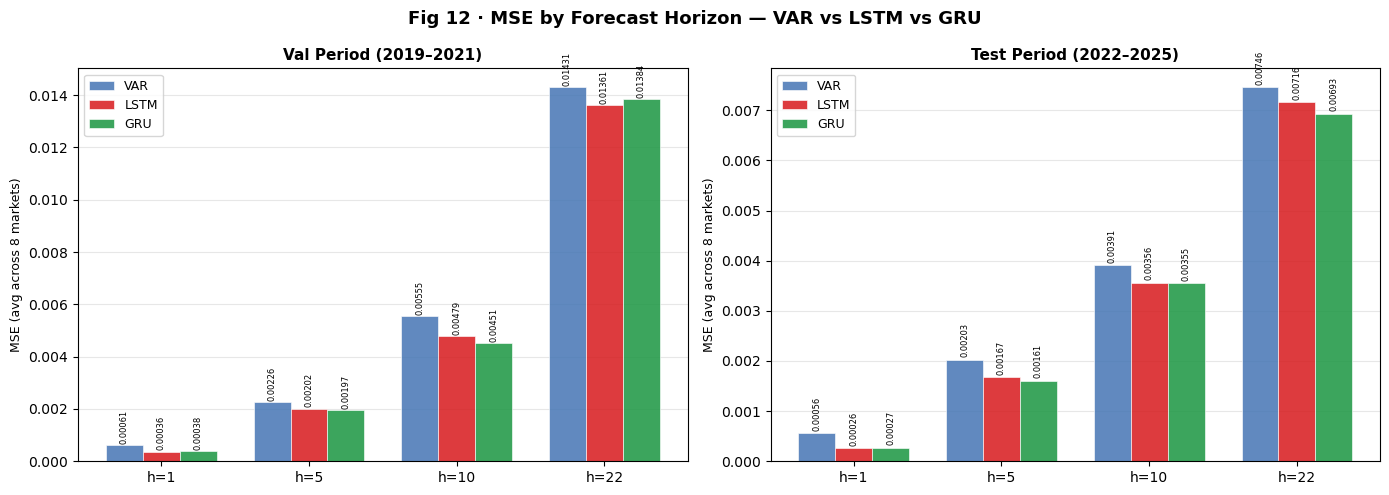

Saved → ..\outputs\figures\fig12_mse_comparison.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 12 · MSE by Forecast Horizon — VAR vs LSTM vs GRU",
             fontsize=13, fontweight="bold")

x      = np.arange(len(HORIZONS))
width  = 0.25
models = ["VAR", "LSTM", "GRU"]

for ax, period in zip(axes, ["Val", "Test"]):
    for i, model in enumerate(models):
        mse_vals = []
        for h in HORIZONS:
            cell = all_metrics[
                (all_metrics["Model"] == model) &
                (all_metrics["Horizon"] == h) &
                (all_metrics["Market"] == "AVERAGE") &
                (all_metrics["Label"].str.contains(period))
            ]
            mse_vals.append(cell.iloc[0]["MSE"] if len(cell) > 0 else np.nan)

        bars = ax.bar(x + i * width, mse_vals, width,
                      label=model, color=MODEL_COLORS[model],
                      alpha=0.85, edgecolor="white", linewidth=0.5)
        # Value labels on bars
        for bar, val in zip(bars, mse_vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.00005,
                        f"{val:.5f}", ha="center", va="bottom", fontsize=6, rotation=90)

    ax.set_xticks(x + width)
    ax.set_xticklabels([f"h={h}" for h in HORIZONS], fontsize=10)
    ax.set_ylabel("MSE (avg across 8 markets)", fontsize=9)
    ax.set_title(f"{period} Period (2019–2021)" if period == "Val" else
                 f"{period} Period (2022–2025)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig12_mse_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## 6 · Fig 13 · MAPE Degradation by Horizon

Line chart showing how MAPE increases with forecast horizon for each model.  
Captures the non-linear error accumulation pattern discussed in Kumar et al. (2024) §5.4.1.

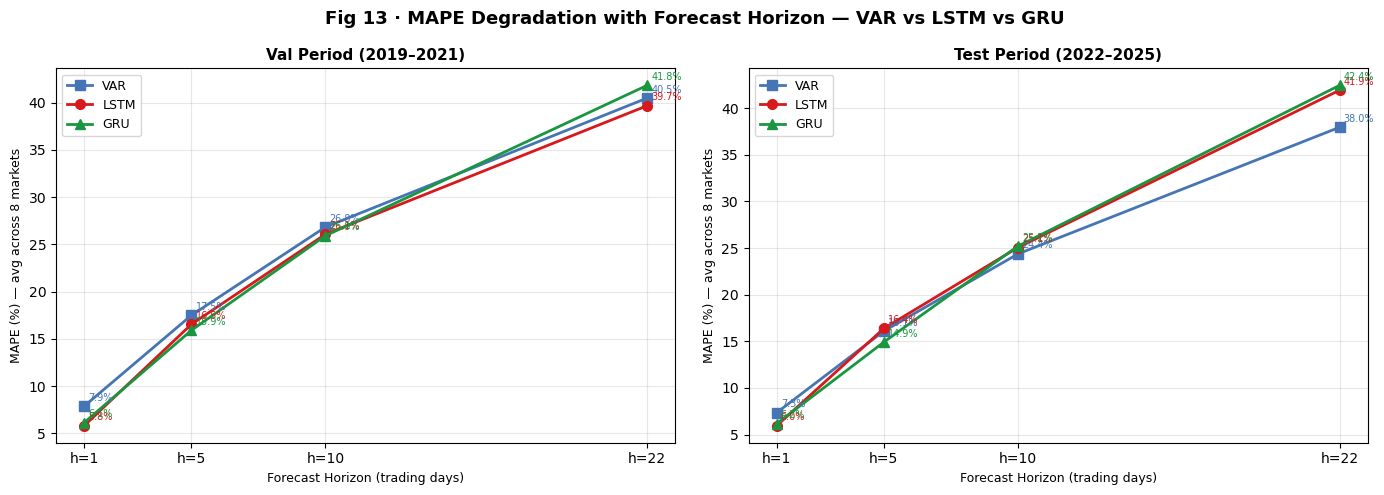

Saved → ..\outputs\figures\fig13_mape_degradation.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 13 · MAPE Degradation with Forecast Horizon — VAR vs LSTM vs GRU",
             fontsize=13, fontweight="bold")

markers = {"VAR": "s", "LSTM": "o", "GRU": "^"}  

for ax, period in zip(axes, ["Val", "Test"]):
    for model in models:
        mape_vals = []
        for h in HORIZONS:
            cell = all_metrics[
                (all_metrics["Model"] == model) &
                (all_metrics["Horizon"] == h) &
                (all_metrics["Market"] == "AVERAGE") &
                (all_metrics["Label"].str.contains(period))
            ]
            mape_vals.append(cell.iloc[0]["MAPE"] if len(cell) > 0 else np.nan)

        ax.plot(HORIZONS, mape_vals,
                color=MODEL_COLORS[model], marker=markers[model],
                lw=2.0, ms=7, label=model)
        for h, v in zip(HORIZONS, mape_vals):
            ax.annotate(f"{v:.1f}%", xy=(h, v), xytext=(3, 4),
                        textcoords="offset points", fontsize=7,
                        color=MODEL_COLORS[model])

    ax.set_xlabel("Forecast Horizon (trading days)", fontsize=9)
    ax.set_ylabel("MAPE (%) — avg across 8 markets", fontsize=9)
    ax.set_title(f"{period} Period (2019–2021)" if period == "Val" else
                 f"{period} Period (2022–2025)",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels([f"h={h}" for h in HORIZONS])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig13_mape_degradation.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## 7 · Fig 14 · DirAcc vs Random Benchmark (0.50)

Direction accuracy across models and horizons.  
Random walk benchmark = 0.50 (dashed line).

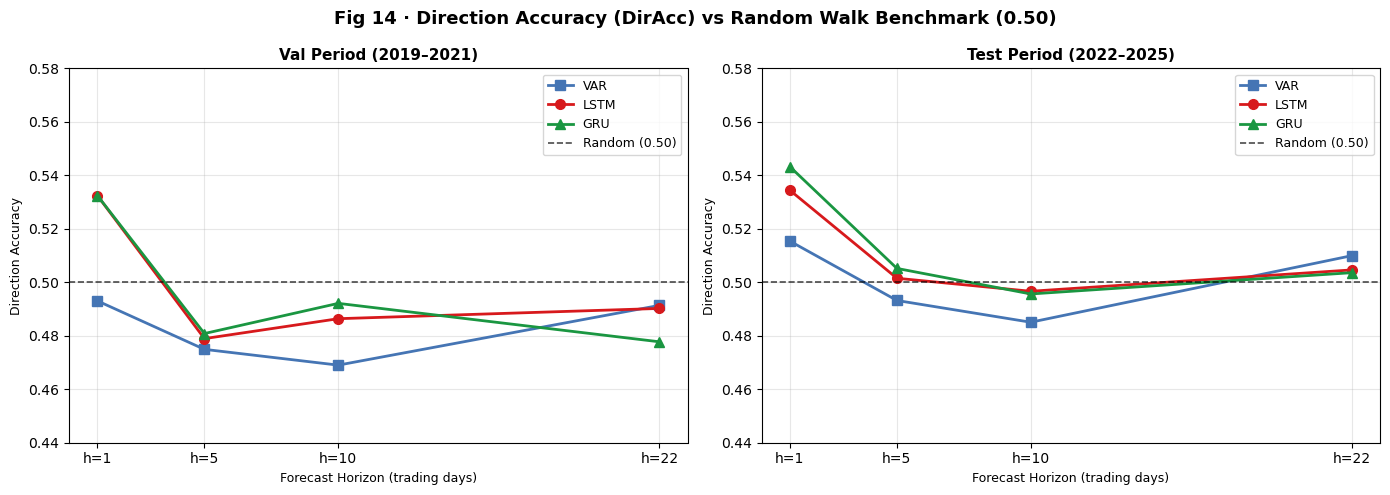

Saved → ..\outputs\figures\fig14_diracc.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 14 · Direction Accuracy (DirAcc) vs Random Walk Benchmark (0.50)",
             fontsize=13, fontweight="bold")

for ax, period in zip(axes, ["Val", "Test"]):
    for model in models:
        dacc_vals = []
        for h in HORIZONS:
            cell = all_metrics[
                (all_metrics["Model"] == model) &
                (all_metrics["Horizon"] == h) &
                (all_metrics["Market"] == "AVERAGE") &
                (all_metrics["Label"].str.contains(period))
            ]
            dacc_vals.append(cell.iloc[0]["Dir_Acc"] if len(cell) > 0 else np.nan)

        ax.plot(HORIZONS, dacc_vals,
                color=MODEL_COLORS[model], marker=markers[model],
                lw=2.0, ms=7, label=model)

    ax.axhline(0.50, color="black", lw=1.2, linestyle="--",
               label="Random (0.50)", alpha=0.7)
    ax.set_ylim(0.44, 0.58)
    ax.set_xlabel("Forecast Horizon (trading days)", fontsize=9)
    ax.set_ylabel("Direction Accuracy", fontsize=9)
    ax.set_title(f"{period} Period (2019–2021)" if period == "Val" else
                 f"{period} Period (2022–2025)",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels([f"h={h}" for h in HORIZONS])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig14_diracc.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## 8 · Fig 15 · Regime Amplification Ratio D/B

Bar chart comparing D/B MSE amplification ratio across models.  
Core war-shock finding: does non-linear modelling improve or degrade under extreme regime switch?

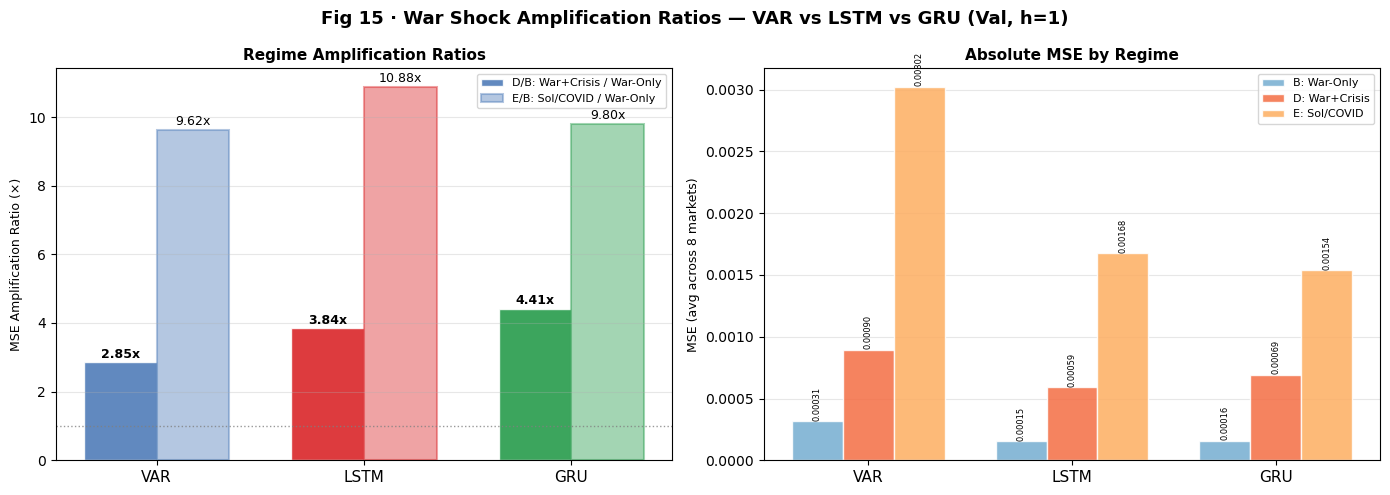

Saved → ..\outputs\figures\fig15_regime_amplification.png


In [32]:
regime_data = {
    "VAR" : regime_var,
    "LSTM": regime_lstm,
    "GRU" : regime_gru,
}

# Compute ratios
ratio_db   = {}  # D/B
ratio_eb   = {}  # E/B (Sol/COVID vs War-Only)
abs_b_mse  = {}  # absolute MSE in B
abs_d_mse  = {}  # absolute MSE in D

for model, res in regime_data.items():
    b = res["B: War-Only"]["MSE"]
    d = res["D: War+Crisis"]["MSE"]
    e = res["E: Sol/COVID"]["MSE"]
    ratio_db[model]  = d / b
    ratio_eb[model]  = e / b
    abs_b_mse[model] = b
    abs_d_mse[model] = d

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 15 · War Shock Amplification Ratios — VAR vs LSTM vs GRU (Val, h=1)",
             fontsize=13, fontweight="bold")

# Left: D/B and E/B ratios
ax = axes[0]
x  = np.arange(3)
w  = 0.35
db_vals = [ratio_db[m] for m in models]
eb_vals = [ratio_eb[m] for m in models]

bars1 = ax.bar(x - w/2, db_vals, w, label="D/B: War+Crisis / War-Only",
               color=[MODEL_COLORS[m] for m in models], alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + w/2, eb_vals, w, label="E/B: Sol/COVID / War-Only",
               color=[MODEL_COLORS[m] for m in models], alpha=0.4,
               edgecolor=[MODEL_COLORS[m] for m in models], linewidth=1.5)

for bar, val in zip(bars1, db_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, val in zip(bars2, eb_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}x", ha="center", va="bottom", fontsize=9)

ax.axhline(1.0, color="gray", lw=1.0, linestyle=":", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("MSE Amplification Ratio (×)", fontsize=9)
ax.set_title("Regime Amplification Ratios", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Right: Absolute MSE by regime
ax2 = axes[1]
regime_plot = ["B: War-Only", "D: War+Crisis", "E: Sol/COVID"]
regime_colors = ["#74add1", "#f46d43", "#fdae61"]
x2 = np.arange(len(models))
w2 = 0.25

for i, (regime, color) in enumerate(zip(regime_plot, regime_colors)):
    vals = [regime_data[m][regime]["MSE"] for m in models]
    bars = ax2.bar(x2 + i*w2, vals, w2, label=regime, color=color,
                   alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.000005,
                 f"{val:.5f}", ha="center", va="bottom", fontsize=6, rotation=90)

ax2.set_xticks(x2 + w2)
ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel("MSE (avg across 8 markets)", fontsize=9)
ax2.set_title("Absolute MSE by Regime", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig15_regime_amplification.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## 9 · Fig 16 · Per-Market MSE Heatmap (Test, h=1)

Reveals cross-sectional heterogeneity in model performance across the 8 markets.  
Following Kumar et al. (2024) Table 2 per-index breakdown.

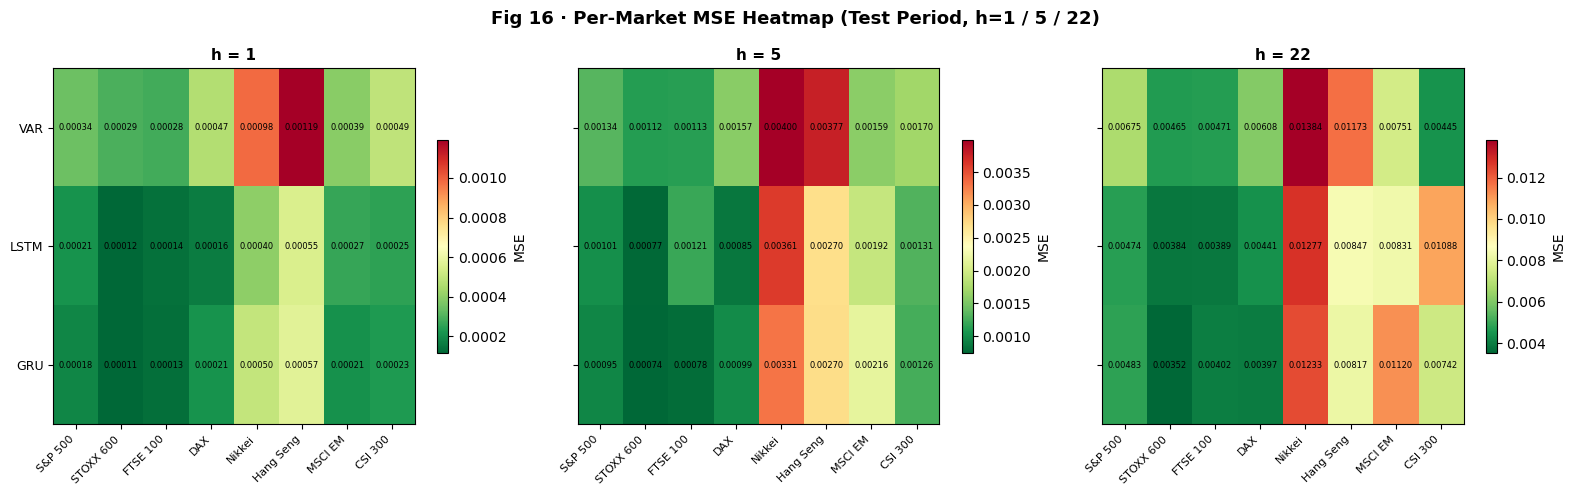

Saved → ..\outputs\figures\fig16_per_market_heatmap.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Fig 16 · Per-Market MSE Heatmap (Test Period, h=1 / 5 / 22)",
             fontsize=13, fontweight="bold")

mkt_display = [MARKET_LABELS[c] for c in EQUITY_COLS]

for ax, h in zip(axes, [1, 5, 22]):
    matrix = []
    for model in models:
        row_vals = []
        for mkt in EQUITY_COLS:
            mkt_key = mkt.replace("_vol", "")
            cell = all_metrics[
                (all_metrics["Model"] == model) &
                (all_metrics["Horizon"] == h) &
                (all_metrics["Market"] == mkt_key) &
                (all_metrics["Label"].str.contains("Test"))
            ]
            row_vals.append(cell.iloc[0]["MSE"] if len(cell) > 0 else np.nan)
        matrix.append(row_vals)

    mat = np.array(matrix)  # shape (3, 8)
    im  = ax.imshow(mat, aspect="auto", cmap="RdYlGn_r")

    ax.set_xticks(range(len(EQUITY_COLS)))
    ax.set_xticklabels(mkt_display, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(3))
    ax.set_yticklabels(models, fontsize=9)
    ax.set_title(f"h = {h}", fontsize=11, fontweight="bold")

    for i in range(3):
        for j in range(len(EQUITY_COLS)):
            v = mat[i, j]
            ax.text(j, i, f"{v:.5f}", ha="center", va="center",
                    fontsize=6, color="black")

    plt.colorbar(im, ax=ax, shrink=0.6, label="MSE")

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig16_per_market_heatmap.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")

## 10 · Save All Output Tables

In [34]:
# Table 1: Master comparison (Val + Test)
with pd.ExcelWriter(os.path.join(TABLE_DIR, "table_master_comparison.xlsx")) as writer:
    table_val.to_excel(writer,  sheet_name="Val_MSE_MAPE")
    table_test.to_excel(writer, sheet_name="Test_MSE_MAPE")
print("Saved → table_master_comparison.xlsx")

# Table 2: Average summary
summary_df.to_excel(os.path.join(TABLE_DIR, "table_average_summary.xlsx"), index=False)
print("Saved → table_average_summary.xlsx")

# Table 3: Regime metrics
regime_df.to_excel(os.path.join(TABLE_DIR, "table_regime_metrics.xlsx"))
print("Saved → table_regime_metrics.xlsx")

# Ratio summary
ratio_rows = []
for model in models:
    ratio_rows.append({
        "Model"      : model,
        "B_MSE"      : regime_data[model]["B: War-Only"]["MSE"],
        "D_MSE"      : regime_data[model]["D: War+Crisis"]["MSE"],
        "E_MSE"      : regime_data[model]["E: Sol/COVID"]["MSE"],
        "D_B_ratio"  : ratio_db[model],
        "E_B_ratio"  : ratio_eb[model],
    })
ratio_df = pd.DataFrame(ratio_rows)
ratio_df.to_excel(os.path.join(TABLE_DIR, "table_regime_amplification.xlsx"), index=False)
print("Saved → table_regime_amplification.xlsx")

Saved → table_master_comparison.xlsx
Saved → table_average_summary.xlsx
Saved → table_regime_metrics.xlsx
Saved → table_regime_amplification.xlsx
